In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np
import sys
sys.path.append('/DATACENTER4/jiangbo.chai/SWJTU_OOPAO')
from OOPAO.Atmosphere import Atmosphere
from OOPAO.DeformableMirror import DeformableMirror
from OOPAO.MisRegistration import MisRegistration
from OOPAO.Pyramid import Pyramid
from OOPAO.ShackHartmann import ShackHartmann
from OOPAO.Source import Source
from OOPAO.Telescope import Telescope
from OOPAO.calibration.ao_calibration import ao_calibration
from OOPAO.calibration.compute_KL_modal_basis import compute_M2C
from OOPAO.tools.displayTools import displayMap


ModuleNotFoundError: No module named 'OOPAO'

In [2]:
# 创建望远镜
tel = Telescope(resolution          = 512, # 分辨率
                diameter            = 4, # 直径
                samplingTime        = 1/1000, # 采样时间
                centralObstruction  = 0.2) # 中心遮挡比例

%%%%%%%%%%%%%%%%%%%%%%%%%%%%%% TELESCOPE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
     Diameter             4                [m]        
    Resolution           512             [pixels]     
    Pixel Size           0.01              [m]        
     Surface             12.0              [m2]       
Central Obstruction       20.0        [% of diameter]  
Pixels in the pupil      197668           [pixels]     
      Source             None                         
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
No light propagated through the telescope


In [3]:
# 创建自然引导星
ngs=Source(optBand   = 'I', # 光波段
           magnitude = 5) # 星等，表示光源的亮度
ngs*tel

%%%%%%%%%%%%%%%%%%%%%%%%%%%%% SOURCE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
 Source Wavelength Zenith  Azimuth   Altitude Magnitude    Flux   
           [m]    [arcsec]  [deg]      [m]              [phot/m2/s]
-------------------------------------------------------------------
  NGS    7.9e-07     0        0        inf       5.0    73369565.2
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%% TELESCOPE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
     Diameter             4                [m]        
    Resolution           512             [pixels]     
    Pixel Size           0.01              [m]        
     Surface             12.0              [m2]       
Central Obstruction       20.0        [% of diameter]  
Pixels in the pupil      197668           [pixels]     
    Source NGS          790.0              [nm]       
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
NGS(I) ~~> telescope


-> Computing the initial phase screen...
initial phase screen : 0.28946757316589355 s
ZZt.. : 118.58614945411682 s
ZXt.. : 5.631669044494629 s
XXt.. : 2.711347818374634 s
Done!
-> Computing the initial phase screen...
initial phase screen : 0.13358306884765625 s
ZZt.. : 2.1457672119140625e-06 s
ZXt.. : 4.482269287109375e-05 s
XXt.. : 1.0967254638671875e-05 s
SCAO system considered: covariance matrices were already computed!
Done!
-> Computing the initial phase screen...
initial phase screen : 0.1504833698272705 s
ZZt.. : 2.384185791015625e-06 s
ZXt.. : 2.8371810913085938e-05 s
XXt.. : 8.821487426757812e-06 s
SCAO system considered: covariance matrices were already computed!
Done!


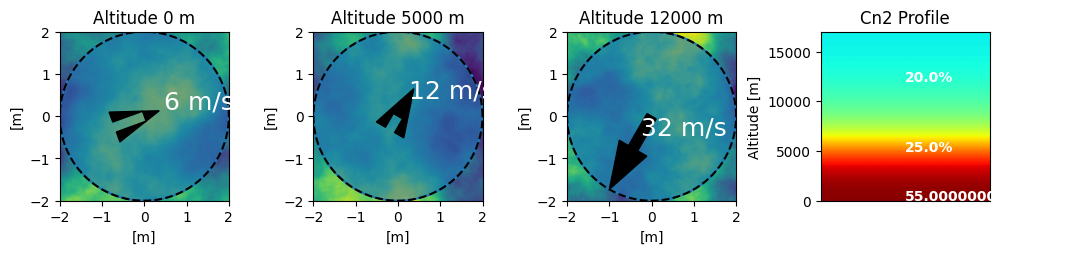

In [4]:
atm=Atmosphere(telescope     = tel,
               r0            = 0.15, # 大气湍流的弗里德参数（Fried parameter），表示大气相干长度，单位为米
               L0            = 30, # 大气湍流的外尺度（Outer scale），单位为米
               windSpeed     = [6, 12, 32] , # 每个湍流层的风速，单位为米/秒
               fractionalR0  = [0.55, 0.25, 0.20], # 每个湍流层的 Cn² 剖面，表示每个层对总湍流的贡献比例
               windDirection = [20, 60, 240], # 每个湍流层的风向，单位为度
               altitude      = [0, 5000, 12000]) # 每个湍流层的海拔高度，单位为米
atm.initializeAtmosphere(telescope=tel) # 初始化
atm.display_atm_layers() # 可视化

In [6]:
atm.print_properties()

%%%%%%%%%%%%%%%%%%%%%%%%%%%%% ATMOSPHERE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%
   Layer     Direction     Speed      Altitude      Cn2     
               [deg]       [m/s]        [m]       [m-2/3]   
----------------------------------------------------------------------
     1           20          6           0          0.55    
------------------------------------------------------------------
     2           60          12         5000        0.25    
------------------------------------------------------------------
     3          240          32        12000        0.2     
------------------------------------------------------------------
    r0 @500 nm         0.15 [m]     
        L0              30 [m]      
  Seeing @500nm        0.69 ["]     
    Frequency        1000.0 [Hz]    
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%


In [5]:
print(tel.isPaired)
tel+atm # 望远镜与大气结合
print(tel.isPaired)

False
True


In [ ]:
# 创建变形镜
dm=DeformableMirror(telescope    = tel,
                    nSubap       = 32, # 沿望远镜直径的变形镜驱动器数，即总驱动数=nSubap*nSubap
                    mechCoupling = 0.1,
                    nThreads=20) # 驱动器之间的机械耦合系数,用于描述变形镜的各个驱动器之间的机械相互作用程度

No coordinates loaded.. taking the cartesian geometry as a default
Generating a Deformable Mirror: 
Computing the 2D zonal modes...
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%% DEFORMABLE MIRROR %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
Controlled Actuators        912        
         M4                False       
        Pitch        0.12121212121212122       [m]        
 Mechanical Coupling        0.1               [%]        
-------------------------------------------------------------------------------
Mis-registration:
Rotation [deg]	Shift X [m]	Shift Y [m]	Radial Scaling [%]	Tangential Scaling [%]
      0       	     0     	     0     	        0         	          0           
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%


In [16]:
# 创建SH-WFS 

wfs = ShackHartmann(nSubap              = 32, #  沿望远镜直径的子孔径数
                    telescope           = tel,
                    lightRatio          = 0.7, # 用于筛选有效子孔径
                    threshold_cog       = 0.01) # 计算光斑质心时的阈值
gainCL                  = 0.6  # 传感增益
print(wfs.nValidSubaperture)

Selecting valid subapertures based on flux considerations..
756


In [17]:
from tutorials.scao_system.parameter_files.parameterFile_VLT_I_Band_SHWFS import initializeParameterFile

param = initializeParameterFile()
param['nModles'] = 200

'''
加载或生成模态基,即模式到控制矩阵（M2C）用于将模式映射到变形镜（DM）的控制信号
计算或加载交互矩阵
'''
ao_calib =  ao_calibration(param            = param,\
                           ngs              = ngs,\
                           tel              = tel,\
                           atm              = atm,\
                           dm               = dm,\
                           wfs              = wfs,\
                           nameFolderIntMat = None,\
                           nameIntMat       = None,\
                           nameFolderBasis  = None,\
                           nameBasis        = None,\
                           nMeasurements    = 100)


Reading/Writting calibration data from data_calibration/
Writting output data in data_cl/
Loading the KL Modal Basis from: data_calibration/M2C_120_res
ERROR: No file found! Taking a zonal basis instead..
Loading Interaction matrix data_calibration/VLT_I_band_20x20/zonal_interaction_matrix_120_res_756_subap_diffractive...
ERROR: No file found! computing imat..
Interaction Matrix Computation:


 10%|█         | 1/10 [00:42<06:19, 42.18s/it]

100/912
Time elapsed: 42.18485641479492 s


 20%|██        | 2/10 [01:14<04:52, 36.58s/it]

200/912
Time elapsed: 32.65260577201843 s


...

 90%|█████████ | 9/10 [06:26<00:56, 56.77s/it]

900/912
Time elapsed: 75.0851137638092 s


100%|██████████| 10/10 [06:31<00:00, 39.14s/it]

1000/912
Time elapsed: 5.166024208068848 s


No Modal Gains found. All gains set to 1


In [18]:
ao_calib.M2C.shape

(912, 912)

In [19]:
from tutorials.scao_system.myAoSystem.Imager import Imager

tel-atm
camH = Imager() # 创建科学相机
camH.clock_rate = 1000 # 时钟频率
camH.exposure_time = 0.2 # 曝光时间
camH.relay(tel.src)
camH.reference_frame = camH.frame # 无湍流情况下的图片
# 闭环控制
calib_CL    = ao_calib.calib # 交互矩阵
M2C_CL      = ao_calib.M2C 

tel+atm
ngs*tel*dm*wfs
# initialize DM commands
dm.coefs=0


param['nLoop'] = 20
# allocate memory to save data
SR                      = np.zeros(param['nLoop']) # 斯特列尔比
SR_old                      = np.zeros(param['nLoop'])
total                   = np.zeros(param['nLoop'])
residual                = np.zeros(param['nLoop'])
wfsSignal               = np.arange(0,wfs.nSignal)*0
# loop parameters
gainCL                  = 0.6  # 传感增益
wfs.cam.photonNoise     = True
wfs.cam.readoutNoise    = 1
wfs.cam.darkCurrent     = 0.0001
display                 = True

for i in range(param['nLoop']):
    a=time.time()
    # 更新所有湍流层的相位屏，模拟时间演化
    atm.update()
    # tel-atm
    # camH.relay(tel.src)
    # camH.reference_frame = camH.frame
    # tel+atm

    # 记录总的波前误差
    total[i]=np.std(tel.OPD[np.where(tel.pupil>0)])*1e9
    
    tel*dm*wfs
    
    '''
    更新DM的控制信号
    dm.coefs：变形镜的控制系数，表示每个驱动器的位移量。 11111
    
    gainCL：闭环控制增益，用于调节校正的强度    11111
    波前传感器的增益,而采样频率通常是和望远镜的采样频率同步的
    
    M2C_CL：模式到控制矩阵，用于将模式映射到变形镜的控制信号。
    calib_CL.M：交互矩阵的伪逆矩阵，用于将波前传感器的信号转换为模式系数。
    wfsSignal:shwfs测量的斜率，形状：（2*nValidSubaperture,）
    ''' 
    dm.coefs=dm.coefs-gainCL*M2C_CL@calib_CL.M@wfsSignal
    
    wfsSignal=wfs.signal
    
    b= time.time()
    print('Elapsed time: ' + str(b-a) +' s')
    
    #实际代码的SR比不通过图像的比来得到，而使用近似的相位差来得到，
    #后续需要修改 改成用科学成像相机的方式来测量斯特列尔比
    SR_old[i]=np.exp(-np.var(tel.src.phase[np.where(tel.pupil==1)]))  
    residual[i]=np.std(tel.OPD[np.where(tel.pupil>0)])*1e9
    camH.relay(tel.src)
    SR[i] = camH.strehl

    print('Loop'+str(i)+'/'+str(param['nLoop'])+' Turbulence: '+str(total[i])+' -- Residual:' +str(residual[i])+ '\n')


Elapsed time: 1.4809091091156006 s
Loop0/20 Turbulence: 761.2168860990532 -- Residual:761.2168860990532

Elapsed time: 1.377013921737671 s
Loop1/20 Turbulence: 756.5555921081998 -- Residual:756.5555921081998

Elapsed time: 1.5081751346588135 s
Loop2/20 Turbulence: 752.0598012319654 -- Residual:305.02633207549843

Elapsed time: 1.559924840927124 s
Loop3/20 Turbulence: 747.7770028809196 -- Residual:232.07656891188847

Elapsed time: 1.5747816562652588 s
Loop4/20 Turbulence: 743.6318760221595 -- Residual:396.2806713003321

Elapsed time: 1.510864019393921 s
Loop5/20 Turbulence: 739.7276797700489 -- Residual:345.13493550651157

Elapsed time: 1.5264310836791992 s
Loop6/20 Turbulence: 736.0501576329084 -- Residual:262.67104434431184

Elapsed time: 1.5513522624969482 s
Loop7/20 Turbulence: 732.6332362131122 -- Residual:457.177305211576

Elapsed time: 1.6102848052978516 s
Loop8/20 Turbulence: 729.519212826336 -- Residual:319.9079393214109

Elapsed time: 1.5153470039367676 s
Loop9/20 Turbulence: 

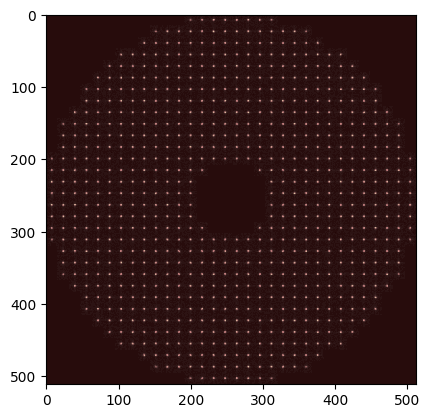

In [14]:
plt.imshow(wfs.cam.frame,cmap='pink')

Text(0.5, 1.0, 'open loop')

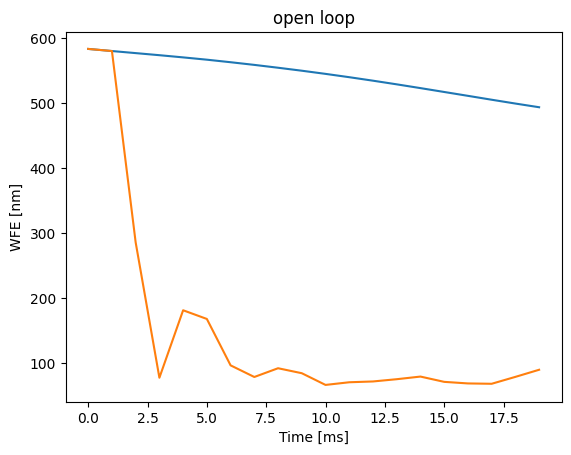

In [26]:
# 波前误差
plt.figure()
plt.plot(total)
plt.plot(residual)
plt.xlabel('Time [ms]')
plt.ylabel('WFE [nm]')
plt.title('open loop')


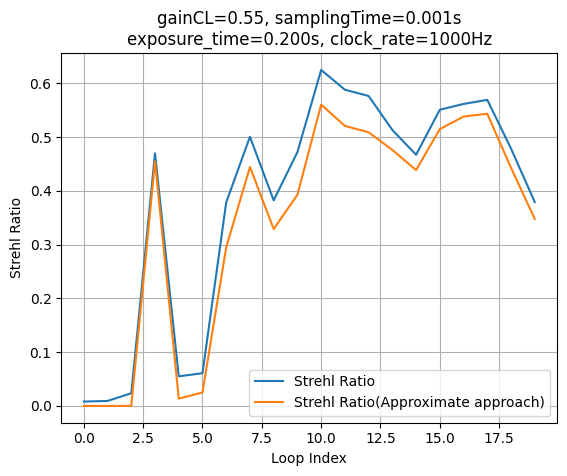

In [27]:
plt.figure()
plt.plot(np.arange(param['nLoop']), SR, label='Strehl Ratio')
plt.plot(np.arange(param['nLoop']), SR_old, label='Strehl Ratio(Approximate approach)')
plt.xlabel('Loop Index')
plt.ylabel('Strehl Ratio')
plt.title(  f"gainCL={gainCL:.2f}, "
            f"samplingTime={tel.samplingTime:.3f}s\n"
            f"exposure_time={camH.exposure_time:.3f}s, "
            f"clock_rate={camH.clock_rate:.0f}Hz")
plt.legend()
plt.grid()
plt.show()

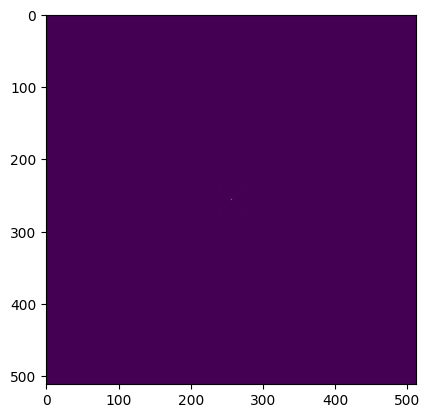

In [28]:
plt.imshow(camH.frame)

In [8]:
import numpy as np
import matplotlib.pyplot as plt
# 加载 .npz 文件
data = np.load("../logdir/WindSpeed_Direction_Experiment/3-1/train_eps/20260104T123939-8e9821500a284e41941413dbd46d1242-501.npz")

# 查看文件中包含的数组名称
print("文件中的数组键名:", list(data.keys()))

# 提取数据（假设文件中有一个名为 'arr_0' 的数组）
action = data["action"]  # 根据实际键名调整
print(action.shape)
reward = data["reward"]
print(reward.shape)

文件中的数组键名: ['image', 'dmCoefs', 'wfsSingnal', 'is_terminal', 'is_first', 'reward', 'discount', 'action', 'logprob']
(501, 78)
(501,)


In [6]:
reward[200],reward[199]

(0.5671245, 0.44999743)

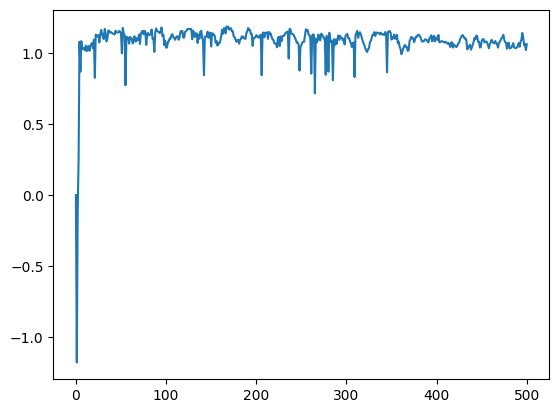

In [9]:
plt.plot(reward)

Plot saved to action_analysis.png, steps: 501


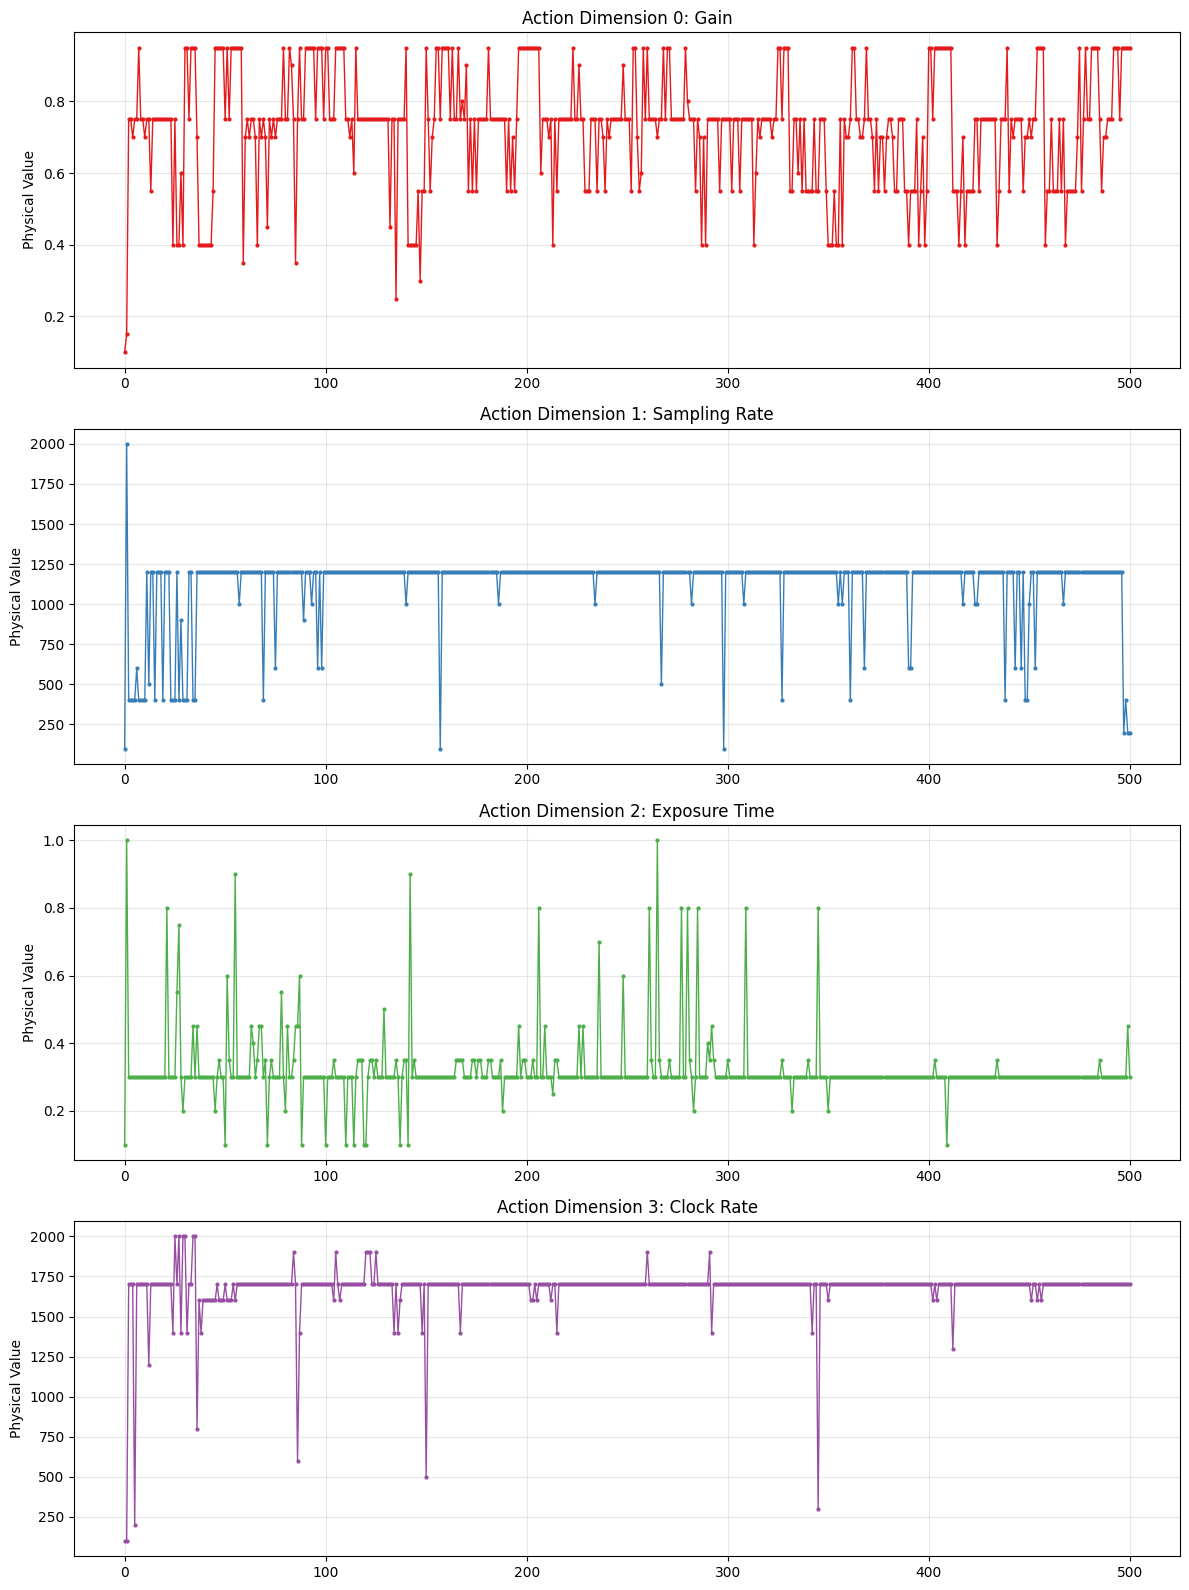

In [10]:
# 定义物理映射（请根据你的实际环境调整数值）
gain_values = np.round(np.linspace(0.1, 1.0, 19), 2)
sr_values = np.arange(100, 2100, 100)
exp_values = np.round(np.linspace(0.1, 1.0, 19), 2)
clock_values = np.arange(100, 2100, 100)

all_maps = [gain_values, sr_values, exp_values, clock_values]
names = ['Gain', 'Sampling Rate', 'Exposure Time', 'Clock Rate']
nvec = [19, 20, 19, 20]
colors = ['#E41A1C', '#377EB8', '#4DAF4A', '#984EA3']
actions_onehot = data['action'] 
steps = actions_onehot.shape[0]

# 2. 解码 One-hot 并转换物理值
decoded_values = [[] for _ in range(4)]

for t in range(steps):
    pointer = 0
    for i, dim in enumerate(nvec):
        # 截取当前维度的 one-hot 段
        sub_action = actions_onehot[t, pointer : pointer + dim]
        # 取 argmax 获得索引
        idx = np.argmax(sub_action)
        # 映射到物理值
        val = all_maps[i][idx]
        decoded_values[i].append(val)
        pointer += dim

# 3. 绘图 (不使用 show, 直接 save)
fig, axs = plt.subplots(4, 1, figsize=(12, 16))

for i in range(4):
    axs[i].plot(range(steps), decoded_values[i], color=colors[i], marker='o', markersize=2, linestyle='-', linewidth=1)
    axs[i].set_title(f'Action Dimension {i}: {names[i]}')
    axs[i].set_ylabel('Physical Value')
    axs[i].grid(True, alpha=0.3)

plt.tight_layout()
# plt.savefig('action_analysis.png') # 保存到当前目录
print(f"Plot saved to action_analysis.png, steps: {steps}")

